# TheLook eCommerce: data quality and core analysis

## tl;dr

- Gross sales: **$10,796,335.70**; net sales after cancellations and returns: **$8,096,531.48**.
- Sessions: **680,862**; conversion: **26.56%**; cart abandonment: **58.00%**.
- The latest source month is partial and is excluded from default period comparisons.
- Invalid shipment-before-item timestamps are excluded from delivery lead-time measures.

## Context & Methods

This notebook is the reproducible companion to the SQL warehouse and Power BI blueprint. It reads generated marts, validates the most decision-relevant checks, and visualizes acquisition, commercial, cohort, and operations evidence.

### Key Assumptions

- Net sales excludes Cancelled and Returned item value.
- Sessions are derived inside SQL from `events.csv` grouped by `session_id`; no source session file is used.
- Funnel conversion uses those derived sessions, not event rows.
- Customer retention means a later month with at least one non-cancelled/non-returned purchase.
- May 2024 is incomplete.

## Data

### 1. Load generated marts

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
ANALYSIS_DIR = PROJECT_ROOT / "data" / "processed" / "analysis"
QA_DIR = PROJECT_ROOT / "outputs" / "qa"

sales = pd.read_csv(ANALYSIS_DIR / "sales_monthly.csv", parse_dates=["month_start"])
channels = pd.read_csv(ANALYSIS_DIR / "channel_quality.csv")
acquisition = pd.read_csv(ANALYSIS_DIR / "acquisition_source_value.csv")
categories = pd.read_csv(ANALYSIS_DIR / "product_performance_category.csv")
cohorts = pd.read_csv(ANALYSIS_DIR / "cohort_retention.csv", parse_dates=["cohort_month"])
qa = pd.read_csv(QA_DIR / "test_results.csv")

{"sales_rows": len(sales), "channel_rows": len(channels), "acquisition_rows": len(acquisition), "category_rows": len(categories), "qa_status": qa["status"].value_counts().to_dict()}

{'sales_rows': 65,
 'channel_rows': 5,
 'acquisition_rows': 5,
 'category_rows': 36,
 'qa_status': {'PASS': 18, 'WARN': 3}}

### 2. Check blocking data-quality tests

In [2]:
blocking_failures = qa[qa["status"] == "FAIL"]
assert blocking_failures.empty, blocking_failures
qa[qa["status"] != "PASS"][["check_name", "severity", "failure_count", "failure_rate", "notes"]]

,check_name,severity,failure_count,failure_rate,notes
16,shipping_not_before_item_created,HIGH,35440,0.195951,Known source anomaly: exclude invalid rows fro...
19,events_user_id_missing,INFO,1124527,0.464554,Event user_id is sparse; session customer_id u...
20,partial_latest_month,INFO,1,1.000000,The maximum source month is partial and exclud...


## Results

### 3. Monthly commercial performance

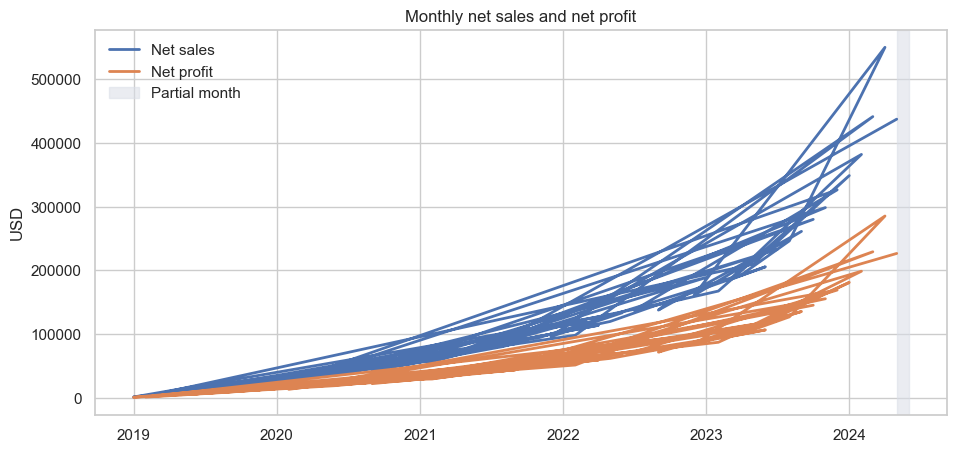

In [3]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sales["month_start"], sales["net_sales_value"], label="Net sales", linewidth=2)
ax.plot(sales["month_start"], sales["net_profit_value"], label="Net profit", linewidth=2)
partial = sales[sales["is_complete_month"] == 0]
if not partial.empty:
    ax.axvspan(partial["month_start"].min(), partial["month_start"].max() + pd.offsets.MonthEnd(1), color="#D9DEE7", alpha=.55, label="Partial month")
ax.set(title="Monthly net sales and net profit", xlabel="", ylabel="USD")
ax.legend(frameon=False);

### 4. Acquisition-source quality

In [4]:
from IPython.display import display
display(
    channels.sort_values("sessions", ascending=False)[
        ["traffic_source", "sessions", "session_conversion_rate", "cart_abandonment_rate"]
    ].style.format({
        "session_conversion_rate": "{:.1%}",
        "cart_abandonment_rate": "{:.1%}",
    })
)
display(
    acquisition.sort_values("net_sales_value", ascending=False)[
        ["acquisition_source", "customers", "orders", "net_sales_value", "net_sales_per_customer"]
    ].style.format({
        "net_sales_value": "${:,.0f}",
        "net_sales_per_customer": "${:,.2f}",
    })
)

,traffic_source,sessions,session_conversion_rate,cart_abandonment_rate
4,Email,306377,26.6%,58.0%
0,Adwords,203690,26.5%,58.0%
1,YouTube,68524,26.5%,58.1%
2,Facebook,68518,26.8%,57.9%
3,Organic,33753,26.4%,58.2%


,acquisition_source,customers,orders,net_sales_value,net_sales_per_customer
4,Search,56086,87383,"$5,670,117",$101.10
0,Organic,11949,18599,"$1,199,982",$100.43
1,Facebook,4796,7571,"$494,458",$103.10
3,Email,4058,6280,"$412,225",$101.58
2,Display,3206,4981,"$319,750",$99.73


### 5. Product portfolio

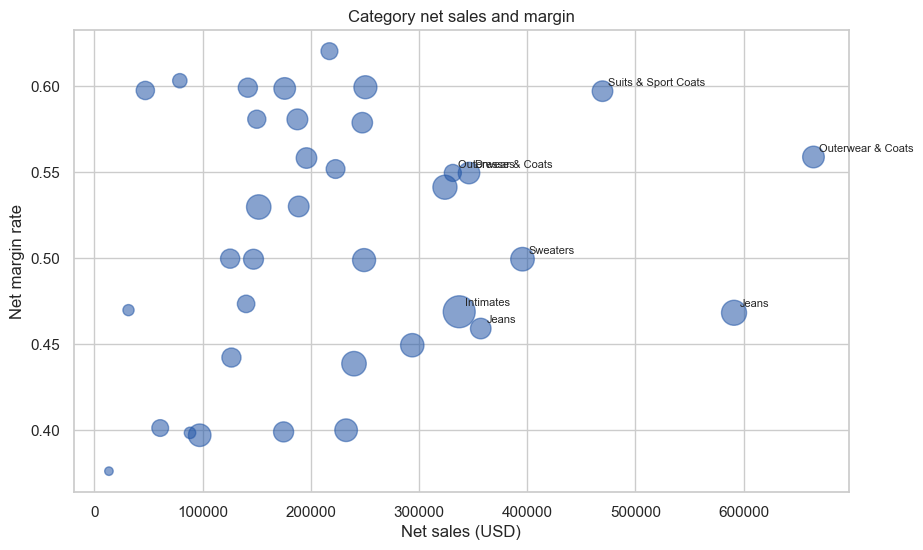

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(categories["net_sales_value"], categories["net_margin_rate"],
           s=categories["items"] / categories["items"].max() * 500 + 30,
           alpha=.55, color="#2457A7")
for _, row in categories.nlargest(8, "net_sales_value").iterrows():
    ax.annotate(row["category"], (row["net_sales_value"], row["net_margin_rate"]), xytext=(4,4), textcoords="offset points", fontsize=8)
ax.set(title="Category net sales and margin", xlabel="Net sales (USD)", ylabel="Net margin rate");

### 6. Purchase cohort retention

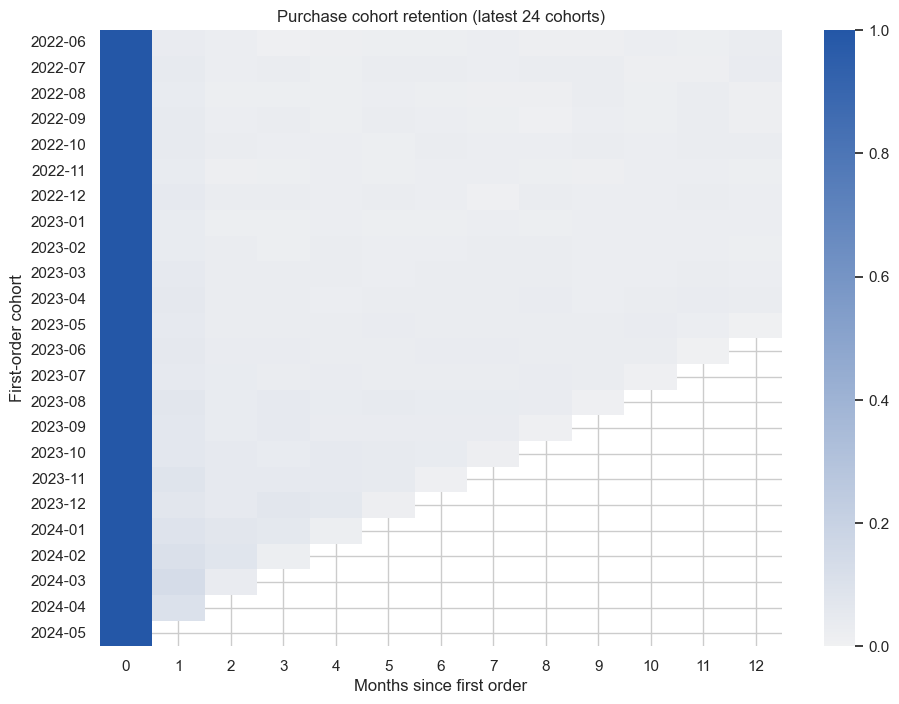

In [6]:
latest = cohorts[cohorts["months_since_first_order"].between(0, 12)].copy()
latest["cohort_label"] = latest["cohort_month"].dt.strftime("%Y-%m")
matrix = latest.pivot(index="cohort_label", columns="months_since_first_order", values="retention_rate").tail(24)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(matrix, cmap=sns.light_palette("#2457A7", as_cmap=True), vmin=0, vmax=1, ax=ax)
ax.set(title="Purchase cohort retention (latest 24 cohorts)", xlabel="Months since first order", ylabel="First-order cohort");

## Takeaways

- Acquisition volume is concentrated, so channel decisions should combine traffic, conversion, abandonment, and attributed net sales.
- Product volume, revenue, and margin are separate decision dimensions.
- Delivery analysis is trustworthy only after filtering invalid timestamp sequences and showing valid-record coverage.
- The generated star schema and DAX measures are the production-facing handoff; this notebook preserves the analytical audit trail.